In [ ]:
import pandas as pd
import sympy as sp
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\maril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### 6.1 Identificação dos parâmetros de um sistema massa mola

### (a) Obtenção da Função de Transferência e Parâmetros

Sabendo que a equação de movimento é:
$$m\ddot{x} + b\dot{x} + kx = f(t)$$

Ao aplicarmos a **Transformada de Laplace** com condições iniciais nulas, obtemos:
$$(ms^2 + bs + k)X(s) = F(s)$$

A função de transferência bruta é:
$$\frac{X(s)}{F(s)} = \frac{1}{ms^2 + bs + k}$$

Para chegar à forma canônica de segunda ordem, dividimos o numerador e o denominador pela constante $k$:
$$\frac{X(s)}{F(s)} = \frac{\frac{1}{k}}{ \frac{m}{k}s^2 + \frac{b}{k}s + 1}$$

---

### Identificação dos Parâmetros

A partir da forma normalizada, podemos identificar os seguintes parâmetros do sistema:

**1. Ganho Estático ($K$)** Representa o valor de regime permanente para uma entrada de degrau unitário:
$$K = \frac{1}{k}$$

**2. Frequência Natural ($\omega_n$)** Representa a frequência na qual o sistema oscilaria caso não houvesse amortecimento:
$$\omega_n = \sqrt{\frac{k}{m}}$$

**3. Fator de Amortecimento ($\zeta$)** Determina o comportamento oscilatório e o quão rápido as oscilações decaem:
$$\zeta = \frac{b}{2 \sqrt{m \cdot k}}$$

### (b) Análise de Parâmetros do Sistema de Segunda Ordem

Sabendo que:

* **Valor final** = $K$
* **Tempo de Subida** ($t_r$) (10% a 90%): 
$$t_r = \frac{1.8}{\omega_n}$$
* **Tempo de Estabilização** ($t_s$) (2%): 
$$t_s = \frac{4}{\zeta \omega_n}$$
* **Valor de pico** ($M_p$): 
$$M_p = e^{-\frac{\pi \zeta}{\sqrt{1-\zeta^2}}}$$

Substituindo os valores de $\zeta$ e $\omega_n$ encontrados anteriormente, temos as expressões em função das propriedades físicas:

$$t_r = \frac{1.8}{\sqrt{\frac{k}{m}}}$$

$$t_s = \frac{4}{\left(\frac{b}{2\sqrt{m \cdot k}}\right) \left(\sqrt{\frac{k}{m}}\right)}$$

$$M_p = e^{-\frac{\pi \left(\frac{b}{2\sqrt{m \cdot k}}\right)}{\sqrt{1-\left(\frac{b}{2\sqrt{m \cdot k}}\right)^2}}}$$

---

### Efeito do Aumento de Parâmetros

A tabela abaixo resume como o aumento de cada componente ($k$, $b$, $m$) afeta a resposta do sistema:

| Parâmetro | $\uparrow k$ (Mola) | $\uparrow b$ (Amortecedor) | $\uparrow m$ (Massa) |
| :--- | :---: | :---: | :---: |
| **Valor final ($K$)** | D | NA | NA |
| **Tempo de Subida ($t_r$)** | D | NA | A |
| **Tempo de Estabilização ($t_s$)** | NA | D | A |
| **Valor de pico ($M_p$)** | A | D | A |

> *Legenda: **A** (Aumenta), **D** (Diminui), **NA** (Não se altera significativamente).*

### (c)

Nesse item, usaremos o **RA 188521**, portanto, o último dígito do RA é **1** e iremos analisar o segundo gráfico ("Resposta ao degrau 1"). Para isso, seguiremos os passos abaixo:

## 1. Identificar o Valor Final e o Ganho ($K$)
O valor final do gráfico converge para aproximadamente **0,33**. Como a entrada é um degrau unitário ($u=1$), o ganho estático do sistema é o próprio valor final:
$$K = 0,33$$

## 2. Determinar o Valor de Pico ($M_p$)
O sobressinal máximo ($M_p$) mostra o quanto a resposta ultrapassa o valor final no primeiro pico. Pela inspeção visual do gráfico, vemos que o valor máximo é aproximadamente $0,44$. 

Calculando o $M_p$ relativo:
$$M_p = \frac{0,44 - 0,33}{0,33} \approx 0,33 \text{ (ou 33\%)}$$



## 3. Calcular o Fator de Amortecimento ($\zeta$)
Utilizando a fórmula baseada no sobressinal:
$$\zeta = \frac{|\ln(M_p)|}{\sqrt{\pi^2 + \ln^2(M_p)}}$$
$$\zeta = \frac{|\ln(0,33)|}{\sqrt{\pi^2 + \ln^2(0,33)}} \approx 0,28$$

## 4. Calcular a Frequência Natural ($\omega_n$)
No eixo horizontal do gráfico, o tempo de pico ($t_p$) — instante onde ocorre o valor máximo — é de aproximadamente **3,2 segundos**. 

A frequência natural é calculada por:
$$\omega_n = \frac{\pi}{t_p\sqrt{1-\zeta^2}}$$
$$\omega_n = \frac{\pi}{3,2\sqrt{1-0,28^2}} \approx 1,01 \text{ rad/s}$$

## 5. Função de Transferência
Substituindo os valores na forma canônica de segunda ordem:
$$G(s) = \frac{K \cdot \omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$
$$G(s) = \frac{0,33 \cdot 1,01^2}{s^2 + 2 \cdot 0,28 \cdot 1,01s + 1,01^2}$$

## 6. Parâmetros de Tempo
Podemos validar os tempos de resposta através das aproximações teóricas:

* **Tempo de Subida ($t_r$):**
$$t_r \approx \frac{1,8}{\omega_n} \approx \frac{1,8}{1,01} \approx 1,78 \text{ segundos}$$

* **Tempo de Estabilização ($t_s$ - critério de 2%):**
$$t_s \approx \frac{4}{\zeta\omega_n} \approx \frac{4}{0,28 \cdot 1,01} \approx 14,08 \text{ segundos}$$

## 7. Resumo dos Resultados
* **Ganho ($K$):** 0,33
* **Fator de amortecimento ($\zeta$):** 0,28
* **Frequência natural ($\omega_n$):** 1,01 rad/s
* **Tempo de subida ($t_r$):** 1,78 s
* **Tempo de estabilização ($t_s$):** 14,08 s
* **Tempo de pico ($t_p$):** 3,2 s



### (d) Obtenção dos parâmetros do sistema

In [ ]:
# Parâmetros fornecidos
K = 0.33
zeta = 0.28
wn = 1.01
tr = 1.78
ts = 14.08
tp = 3.2

# 1. Definição da Função de Transferência G(s) = (K * wn^2) / (s^2 + 2*zeta*wn*s + wn^2)
num = [K * wn**2]
den = [1, 2 * zeta * wn, wn**2]
sys = signal.TransferFunction(num, den)

# 2. Gerar a resposta ao degrau
t = np.linspace(0, 45, 1000)
t, y = signal.step(sys, T=t)

# 3. Plotagem
plt.figure(figsize=(10, 6))
plt.plot(t, y, 'b', linewidth=2, label='Resposta ao Degrau')

# Marcando o Valor Final (K)
plt.axhline(y=K, color='r', linestyle='--', alpha=0.5)
plt.text(40, K + 0.01, f'K = {K}', color='r')

# Marcando o Tempo de Pico (tp) e Mp
y_max = np.max(y)
plt.plot(tp, y_max, 'ro')
plt.vlines(tp, 0, y_max, colors='gray', linestyles='dotted')
plt.annotate(f'tp={tp}s', xy=(tp, y_max), xytext=(tp+1, y_max),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# Marcando o Tempo de Subida (tr)
# Aproximadamente onde cruza o valor final pela primeira vez
plt.vlines(tr, 0, K, colors='green', linestyles='dotted')
plt.text(tr-0.5, -0.02, 'tr', color='green', fontweight='bold')

# Marcando o Tempo de Estabilização (ts)
plt.vlines(ts, 0, K, colors='purple', linestyles='dotted')
plt.text(ts-0.5, -0.02, 'ts', color='purple', fontweight='bold')

# Faixa de 2% para o ts
plt.axhline(y=K*1.02, color='gray', linestyle=':', alpha=0.3)
plt.axhline(y=K*0.98, color='gray', linestyle=':', alpha=0.3)

# Configurações de eixos e labels
plt.title('Resposta ao Degrau - Sistema de 2ª Ordem')
plt.xlabel('Tempo (sec)')
plt.ylabel('Amplitude')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(0, 0.5) # Ajustado para o ganho de 0.33
plt.xlim(0, 45)

plt.show()

NameError: name 'signal' is not defined

In [ ]:
file = 'dados1.txt'
D = np.loadtxt(file)

nr, nc = D.shape
X, Y = [], []
for i in range(nr-2):
    X.append([D[i+1,1], D[i,1], -1])
    Y.append(-D[i+2,1])

X = np.array(X)
Y = np.array(Y)

# Solução do MMQ
v = np.linalg.inv(X.T @ X) @ X.T @ Y
a, b_coef, c = v[0], v[1], v[2]
print(f"a = {a}, b_coef = {b_coef}, c = {c}")

# h = y_k - y_k-1
h = D[1,0] - D[0,0]

# my" + by' + cy = f
    # y" = (y_k+1 - 2*y_k + y_k-1) / h^2
    # y' = (y_k+1 - y_k-1) / 2*h
# y_k+1 + a*y_k + b*y_k-1 = c*f_k 

m = h**2 / c
b = (2*m*(a+2)) / h
k = (m*(b_coef-1) + (b*h)/2) / h**2
print(f"m = {m}, b = {b}, k = {k}")

a = -1.8695318732636372, b_coef = 0.8954497085072215, c = 0.008639278437355655
m = 3.1759456088866593, b = 5.003019722594189, k = 2.9999999920731


### 6.2 Polos dominantes, redução de ordem e aproximação de modelos

In [ ]:
''' (a) Observe a resposta ao degrau do sistema de ordem superior e proponha uma aproximação estritamente própria
de primeira ordem para esta planta, ou seja, determine A e τ de forma que: G_ap(s) = A / (τs + 1) forneça uma boa
aproximação para a planta. Verifique se os comportamentos transitório e em regime permanente foram razoavelmente
aproximados, sobrepondo as duas respostas ao degrau. '''


A = 0.264202
τ = 1.684631 s


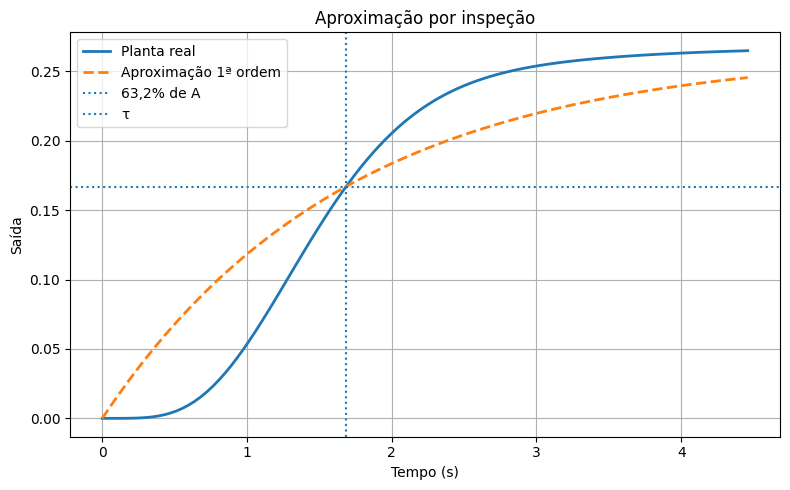

In [ ]:
arquivo = "mod6.txt" 

# cálculo de A e τ

dados = np.loadtxt(arquivo)
t = dados[:, 0]
y = dados[:, 1]

n_final = max(5, int(0.1 * len(y)))
A = np.mean(y[-n_final:])

y63 = 0.632 * A
idx = np.where(y >= y63)[0]

if len(idx) == 0:
    raise ValueError("A resposta não atingiu 63,2% do valor final.")

k = idx[0]

if k == 0:
    tau = t[0]
else:
    t1, t2 = t[k-1], t[k]
    y1, y2 = y[k-1], y[k]
    tau = t1 + (y63 - y1) * (t2 - t1) / (y2 - y1)

print(f"A = {A:.6f}")
print(f"τ = {tau:.6f} s")

# plotar gráfico

y_ap = A * (1 - np.exp(-t / tau))

plt.figure(figsize=(8,5))
plt.plot(t, y, label="Planta real", linewidth=2)
plt.plot(t, y_ap, "--", label="Aproximação 1ª ordem", linewidth=2)
plt.axhline(0.632*A, linestyle=":", label="63,2% de A")
plt.axvline(tau, linestyle=":", label="τ")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.title("Aproximação por inspeção")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
''' Resposta item A

    Neste exercício, a planta foi aproximada por um modelo de primeira ordem, ou seja, G_ap(s) = A / (τs + 1),
a partir da análise da resposta ao degrau unitário do sistema original. A resposta ao degrau de um sistema de
primeira ordem é dado por: y_ap = A * (1 - exp(-t / tau)), onde, A é o ganho estático, ou seja, o valor final
da saída, enquanto τ é a constante de tempo, que indica a rapidez da resposta.
    O valor de A foi estimado a partir do regime permanente da resposta da planta, ou seja, calculou-se a média dos
últimos pontos do vetor de saída, onde o sistema já estava estabilizado. o valor encontrado foi: A = 0.264202.
Em sistemas de primeira ordem, no instante t = τ, a resposta ao degrau atinge aproximadamente 63,2% do valor final,
ou seja, y(τ) = 0.632 * A. Sendo assim, o valor de τ encontrado foi: τ = 1.684631 s.
    Sendo assim, o modelo de primeira ordem fica sendo: G_ap(s) = 0.264202 / (1.684631 s + 1), enquanto a resposta
ao degrau é dada por: y_ap = 0.264202 * (1 - exp(-t / 1.68463)).
    A comparação das duas cruvas sobrepostas no gráfico evidencia que essa aproximação representa adequadamente o
valor final e a dinâmica dominante da planta, embora não reproduza com exatidão o trecho inicial do transitório,
pois plantas de múltiplos polos possuem comportamento em "S" no início. Isso mostra a influência de dinâmicas de
ordem superior no sistema original.

Obs: Neste item foi utilizado o arquivo mod6.txt.
 '''


In [ ]:
''' (b) Se o modelo em questão fosse de fato de primeira ordem, a função de transferência de G_ap(s) acima
o modelaria perfeitamente, implicando que a sua entrada e a sua saída são vinculadas pela equação diferencial:
τ . y_dot(t) + y(t) = A . u(t). Use a resposta ao degrau da planta e o procedimento baseado em diferenças finitas
e quadrados mínimos para estimar A e τ que tornam G_ap(s) uma boa aproximação para a planta. Novamente, sobreponha
as duas respostas ao degrau. Repare que a solução de quadrados mínimos não vai atender adequadamente os objetivos
da questão, pois a preocupação com o transitório leva ao não atendimento do ganho de regime. Adapte então o
problema para o de quadrados mínimos ponderados, dando mais peso para os erros cometidos mais próximos do regime,
forçando assim as duas curvas a convergirem em regime. '''


Quadrados mínimos comuns
α = 0.236793
β = 0.100642
A = 0.425023
τ = 4.223097 s

Quadrados mínimos ponderados
α = 0.608382
β = 0.179234
A = 0.294607
τ = 1.643704 s


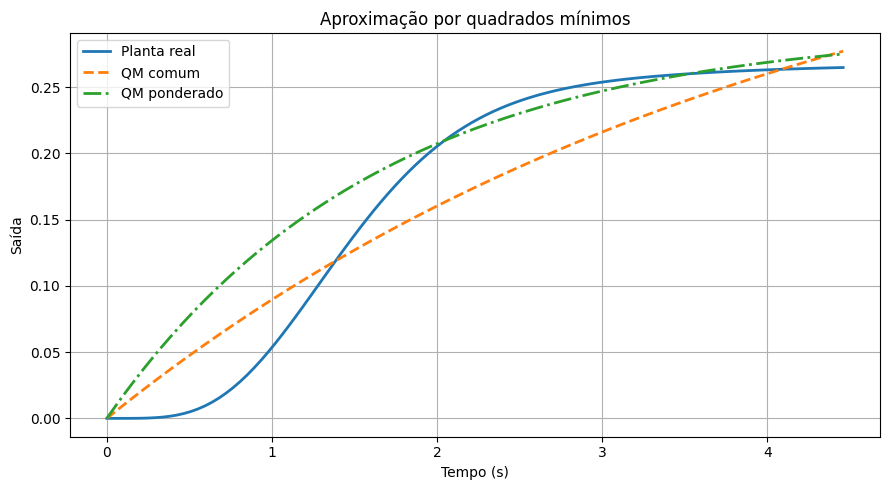

In [ ]:
arquivo = "mod6.txt"   

dados = np.loadtxt(arquivo)
t = dados[:, 0]
y = dados[:, 1]

h = t[1] - t[0]

dy = (y[2:] - y[:-2]) / (2 * h)
yk = y[1:-1]

X = np.column_stack((-yk, np.ones_like(yk)))
Y = dy

# quadrados mínimos comuns

theta_ls, *_ = np.linalg.lstsq(X, Y, rcond=None)
alpha_ls, beta_ls = theta_ls

tau_ls = 1 / alpha_ls
A_ls = beta_ls / alpha_ls


# quadrados mínimos ponderados

q = np.arange(1, len(Y) + 1)   
Q = np.diag(q)

theta_wls = np.linalg.solve(X.T @ Q @ X, X.T @ Q @ Y)
alpha_w, beta_w = theta_wls

tau_w = 1 / alpha_w
A_w = beta_w / alpha_w

# respostas aproximadas ao degrau

y_ls = A_ls * (1 - np.exp(-t / tau_ls))
y_w = A_w * (1 - np.exp(-t / tau_w))

# resultados

print("Quadrados mínimos comuns")
print(f"α = {alpha_ls:.6f}")
print(f"β = {beta_ls:.6f}")
print(f"A = {A_ls:.6f}")
print(f"τ = {tau_ls:.6f} s")

print("\nQuadrados mínimos ponderados")
print(f"α = {alpha_w:.6f}")
print(f"β = {beta_w:.6f}")
print(f"A = {A_w:.6f}")
print(f"τ = {tau_w:.6f} s")


# plotar gráfico

plt.figure(figsize=(9, 5))
plt.plot(t, y, label="Planta real", linewidth=2)
plt.plot(t, y_ls, "--", label="QM comum", linewidth=2)
plt.plot(t, y_w, "-.", label="QM ponderado", linewidth=2)

plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.title("Aproximação por quadrados mínimos")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
''' Resposta item B

    Neste exercício, os parâmetros do modelo de primeira ordem foram estimados por quadrados mínimos a partir da
equação: y_dot(t) = - (1/τ) * y(t) + A/τ, escrita na forma linear: y_dot(t) = - α * y(t) + β.  A derivada da saída
foi aproximada por diferenças finitas centrais, permitindo montar um problema de regressão linear.
    Pelo método de quadrados mínimos comuns, obteve-se: α = 0.236793 e β = 0.100642, resultando em A = 0.425023 e
τ = 4.223097 s. Isso gera o seguinte modelo: G_ap(s) = 0.425023 / (4.223097 s + 1).
    No método de quadrados mínimos ponderados, atribuiu-se pesos crescentes às amostras ao longo do tempo, com o
objetivo de priorizar o ajuste em regime permanente. Nesse caso, obteve-se: α = 0.608382 e β = 0.179234, resultando
em A = 0.294607 e τ = 1.643704 s. Isso gera o seguinte modelo: G_ap(s) = 0.294607 / (1.643704 s + 1).
    Pela sobreposição no gráfico, nota-se que o modelo obtido por quadrados mínimos comuns não representou adequadamente
a planta, pois apresentou resposta mais lenta e valor final superior ao observado no sistema real. Ela tenta compensar
o atraso inicial, gerando erro no valor final de regime. Já o modelo obtido por quadrados mínimos ponderados apresentou
melhor concordância com a resposta da planta, especialmente em regime permanente, além de fornecer um valor de constante
de tempo próximo ao obtido por inspeção no item anterior. Ela não tem tanta precisão no início do transitório, mas a saída
final é mais cindizente com a da planta real.
    
Obs: Neste item foi utilizado o arquivo mod6.txt.
 '''


In [ ]:
''' (c) Discuta a qualidade das aproximações obtidas. O que pode acontecer se o polo mais lento não for suficientemente 
dominante? '''


In [ ]:
''' Resposta item C

    A análise dos resultados mostra que a aproximação da planta por um modelo de primeira ordem é capaz de representar a dinâmica
dominante do sistema, mas não toda a complexidade do transitório da planta original. No item A, a aproximação por inspeção forneceu
o modelo G_ap(s) = 0.264202 / (1.684631 s + 1), que apresentou comportamento coerente com a resposta real. No item B, o ajuste por
quadrados mínimos comuns resultou em G_ap(s) = 0.425023 / (4.223097 s + 1), porém, esse modelo não representou adequadamente a planta,
pois apresentou resposta muito lenta e um alto ganho estático. O ajuste por quadrados mínimos ponderados, por sua vez, levou ao modelo
G_ap(s) = 0.294607 / (1.643704 s + 1), que foi o que apresentou melhor concordância com a planta, em especial no regime permanente.
	Com isso, nota-se que a qualidade da redução de ordem depende da existência de um polo dominante. Quando o polo mais lento é
significativamente dominante, os demais polos possuem pouca influência sobre a resposta, e a aproximação por primeira ordem tem a 
tendência de ser boa. Porém, se essa dominância não for forte o suficiente, os outros polos também afetam bastante o transitório,
o que torna a resposta real diferente da resposta de um sistema de primeira ordem.
 '''
